<a href="https://colab.research.google.com/github/Slavena1/Softuni-Deep-Learning-Final-Project/blob/main/notebook/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Child, Learner, Machine: Benchmarking Real Language Models Against Human Mandarin Acquisition
##### *Author: Slavena Peneva-Kargiou*
##### *Course: SoftUni Deep Learning*
##### *Instructor: Yordan Darakchiev*
##### *Date: August 2026*

Builds on: [SoftUni Machine Learning Final Project](https://github.com/Slavena1/Softuni-Machine-Learning-Final-Project)

In [ ]:
import os

REPO_URL = "https://github.com/Slavena1/Softuni-Deep-Learning-Final-Project.git"
REPO_DIR = "/content/Softuni-Deep-Learning-Final-Project"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}/notebook

Cloning into '/content/Softuni-Deep-Learning-Final-Project'...
remote: Enumerating objects: 876, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 876 (delta 28), reused 3 (delta 1), pack-reused 813 (from 2)
Receiving objects: 100% (876/876), 9.93 MiB | 18.32 MiB/s, done.
Resolving deltas: 100% (150/150), done.
/content/Softuni-Deep-Learning-Final-Project/notebook


In [ ]:
!pip install -q -r ../requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.1/915.1 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, classification_report
)


## 1. Introduction

My Machine Learning project asked a simple question: when Mandarin speakers acquire new vocabulary - as children learning their first language, or as adults learning a second one, what makes a word easy or hard? The answer turned out to depend on who is doing the learning. Children lean on concreteness: words for things you can point at and picture come first. Adult learners lean on frequency: the words you hear most often stick first. A third group sat in that project too, but simply as an assumption rather than a measurement - "the language model" standing in as a kind of frequency-maximizing learner, represented just by a static word-frequency table pulled from the Chinese BabyLM corpus.

This project asks what happens if I stop assuming and start testing, and it turned out to require answering two questions, not one, where the first shaped how I approached the second.

**Question one: does more model capacity actually help predict word-acquisition difficulty?** Starting from the ML project's Ridge/Random Forest baseline on three hand-picked features (frequency, concreteness, word length), I added a neural network on those same features, then a neural network on richer pretrained transformer embeddings, asking at each step whether the added complexity earned its keep.

**Question two: given that answer, what happens when real language models are tested directly?** Rather than the ML project's frequency-table proxy for "the language model", this asks real LLMs directly, the way you would quiz a learner. Then I compare that behavior against the same real human data: which words Mandarin-speaking children learn first, and which words are ranked as harder on the HSK proficiency scale that adult learners study against. Do today's language models look more like the concreteness driven child, the frequency driven adult learner, or something else entirely?

**What is new here, versus the ML project:** that project used Ridge and Random Forest regression on three hand-picked features (frequency, concreteness, word length) to find the pattern in the first place. This project does three additional things:
- replaces the frequency-table proxy for "the language model" with direct behavioral testing of real LLMs, via API;
- adds an actual neural architecture comparison - a dense network trained on pretrained transformer embeddings, using the same frozen-backbone transfer-learning pattern this course teaches for vision and language models, evaluated against the earlier Ridge/RF baseline rather than replacing it outright;
- treats reliability engineering (caching, retries, cost tracking) as part of the methodology, not as an afterthought.




## 2. Related Work
The BabyLM Challenge (Warstadt et al., 2023) anchors the practical part of this project's motivation. It asks what happens if a language model is trained on roughly the amount of text a child actually hears growing up. The English evaluation pipeline built for it includes an age-of-acquisition (AoA) prediction task: check whether a trained model's behavior on a word correlates with the age at which real children acquire it.

The 2026 BabyLM Workshop introduced a new multilingual track built on BabyBabelLM, a training data resource explicitly covering English, Dutch and Chinese (Jumelet et al., 2026), with the year's theme being "going beyond English" - a direct invitation for this kind of non-English acquisition work.  

The Chinese BabyLM Challenge, colocated with NLPCC 2026, extends this to Mandarin and it is where my ML project's corpus came from. Its own evaluation pipeline takes a different shape: grammatical acceptability (NLU), character-level structural knowledge (Hanzi), and alignment with human brain recordings (Cog), but nothing resembling the English pipeline's AoA-prediction task. That's the gap I was intrigued by - I checked this reading of their pipeline directly against their published evaluation code before committing to the idea.

## 3. Data

Same data as the ML project, reloaded here via the same loader functions (src/data_prep.py, unchanged).

In [ ]:
DEST_DIR = '../data'
os.makedirs(DEST_DIR, exist_ok=True)

DRIVE_FOLDER_ID = "13qEDS3YRXskJjXPesqNmPn9uImHmopVl"

!pip install -q gdown
!gdown --folder https://drive.google.com/drive/folders/{DRIVE_FOLDER_ID} -O {DEST_DIR} --remaining-ok

print("Data files staged in", DEST_DIR)

Retrieving folder contents
Processing file 1sb2_Fq67EGy6WySI-44L16wUytFeVlJY babylm_zh_frequencies.csv
Processing file 1W2hW40vBqexq-RVoch0KF2Dv4Z85cJDp Concretenss_Ratings_of_9877_Two_Character_Chinese_Words.xlsx
Processing file 1W1vyo1ufxjPfjKL3uJQPIkt2mnO0J_-_ hsk1.csv
Processing file 1Spv-UH2QiQUwHGchCAKJWzV209wW5ZJ8 hsk2.csv
Processing file 1iy_T3kIPOFdHdBxwjiCDZE7aMM1oSo4H hsk3.csv
Processing file 1-ufI3_Akid9E1VU99Md6xcw500HK-REi hsk4.csv
Processing file 1upUTHWY2ouqbmPoxgy6R3uRhbpoJ_jjP hsk5.csv
Processing file 1wkKtMgsvWGICj-HCY9lejpWlDO-cgpQn hsk6.csv
Processing file 1NlZc9c6awW1SSoxitKXTL8D4n99fFvYg liu_2007_single_char.txt
Processing file 1fy5DUw-bB0yHD1uD5GNpywEf5sJbEqW3 train-00000-of-00001.parquet
Processing file 1LSEbXszjBbNpcCZrCVFtt3qZAcj7lszp wordbank_mandarin_items.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1sb2_Fq67EGy6WySI-44L16wUytFeVlJY
To: /cont

In [ ]:
import sys
sys.path.insert(0, '/content/Softuni-Deep-Learning-Final-Project/src')

import data_prep as dp
import features as ft

DATA_DIR = '../data'

df_aoa = dp.load_wordbank(f'{DATA_DIR}/wordbank_mandarin_items.csv')
hsk_paths = {level: f'{DATA_DIR}/hsk{level}.csv' for level in range(1, 7)}
df_hsk = dp.load_hsk(hsk_paths)
df_freq = dp.load_babylm_frequencies(
    f'{DATA_DIR}/babylm_zh_frequencies.csv',
    parquet_path=f'{DATA_DIR}/train-00000-of-00001.parquet'
)
df_xuli = dp.load_xuli_concreteness(
    f'{DATA_DIR}/Concretenss_Ratings_of_9877_Two_Character_Chinese_Words.xlsx')
df_liu = dp.load_liu_concreteness(f'{DATA_DIR}/liu_2007_single_char.txt')

print(f"Child AoA words: {len(df_aoa)}")
print(f"HSK words: {len(df_hsk)}")
print(f"Frequency table: {len(df_freq)} words")
print(f"Concreteness norms: {len(df_xuli)} (Xu & Li) + {len(df_liu)} (Liu et al.)")

Loaded pre-computed frequencies: 606,029 unique words
Child AoA words: 799
HSK words: 4993
Frequency table: 606029 words
Concreteness norms: 9877 (Xu & Li) + 2356 (Liu et al.)


In [ ]:
# Concreteness merging: Xu & Li (two-character) + Liu et al. (single-character)
df_xuli['concreteness_norm'] = dp.normalize_concreteness(df_xuli['concreteness'])
df_liu['concreteness_norm'] = dp.normalize_concreteness(df_liu['concreteness_raw'])

df_concrete_combined = pd.concat([
    df_xuli[['word', 'concreteness_norm']],
    df_liu[['word', 'concreteness_norm']]
], ignore_index=True)

# Reduplicated words (e.g. 妈妈, 爸爸): concreteness derived from the base character,
# since these carry no independent concreteness rating in either source dataset
liu_lookup = dict(zip(df_liu['word'], df_liu['concreteness_norm']))
missing_conc_words = df_aoa[~df_aoa['word'].isin(df_concrete_combined['word'])]['word'].tolist()
reduplications = [w for w in missing_conc_words if dp.is_reduplication(w)]

reduplication_rows = []
for word in reduplications:
    base_char = word[0]
    if base_char in liu_lookup:
        reduplication_rows.append({'word': word, 'concreteness_norm': liu_lookup[base_char]})
df_reduplications = pd.DataFrame(reduplication_rows)

df_concrete_final = pd.concat(
    [df_concrete_combined, df_reduplications], ignore_index=True
).drop_duplicates(subset='word', keep='first')

print(f"Final concreteness dataset: {len(df_concrete_final):,} unique words")

Final concreteness dataset: 12,250 unique words


In [ ]:
df_child = dp.build_dataset(df_aoa.dropna(subset=['aoa']), 'aoa', df_freq, df_concrete_final)
df_adult = dp.build_dataset(df_hsk, 'hsk_level', df_freq, df_concrete_final)

FEATURES = ['log_frequency', 'concreteness', 'word_length']

df_child_analysis = df_child.dropna(subset=['aoa'] + FEATURES).copy().reset_index(drop=True)
df_adult_analysis = df_adult.dropna(subset=['hsk_level'] + FEATURES).copy().reset_index(drop=True)

print(f"Child analysis dataset: {len(df_child_analysis)} words")
print(f"Adult analysis dataset: {len(df_adult_analysis)} words")

Child analysis dataset: 504 words
Adult analysis dataset: 3269 words


## 4. Methods

### 4.1 Baseline: Ridge/ Random Forest (from the ML project)
This part reuses src/baseline_models.py as it is - same train/test split methodoloy as the ML project (split on the raw data before any preprocessing, use Pipeline for scaling).

In [ ]:
import baseline_models as bm

# Split on raw (unscaled) features - standardization happens inside each
# model's pipeline, fit on training data only
X_c_train, X_c_test, y_c_train, y_c_test, idx_c_train, idx_c_test = bm.split_raw(
    df_child_analysis, FEATURES, 'aoa')

X_a_train, X_a_test, y_a_train, y_a_test, idx_a_train, idx_a_test = bm.split_raw(
    df_adult_analysis, FEATURES, 'hsk_level')

print(f"Child train/test sizes: {len(X_c_train)} / {len(X_c_test)}")
print(f"Adult train/test sizes: {len(X_a_train)} / {len(X_a_test)}")

Child train/test sizes: 378 / 126
Adult train/test sizes: 2451 / 818


In [ ]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_child = bm.fit_ridge(X_c_train, y_c_train, param_grid, cv=cv)
ridge_child = grid_child.best_estimator_
y_c_pred = ridge_child.predict(X_c_test)
cv_scores_child = cross_val_score(ridge_child, X_c_train, y_c_train, cv=cv, scoring='r2')

print(f"Child AoA - Ridge (alpha={grid_child.best_params_['ridge__alpha']}):")
print(f"  R2: {r2_score(y_c_test, y_c_pred):.3f}  |  CV R2: {cv_scores_child.mean():.3f} +/- {cv_scores_child.std():.3f}")

grid_adult = bm.fit_ridge(X_a_train, y_a_train, param_grid, cv=cv)
ridge_adult = grid_adult.best_estimator_
y_a_pred = ridge_adult.predict(X_a_test)
cv_scores_adult = cross_val_score(ridge_adult, X_a_train, y_a_train, cv=cv, scoring='r2')

print(f"\nAdult HSK - Ridge (alpha={grid_adult.best_params_['ridge__alpha']}):")
print(f"  R2: {r2_score(y_a_test, y_a_pred):.3f}  |  CV R2: {cv_scores_adult.mean():.3f} +/- {cv_scores_adult.std():.3f}")

Child AoA - Ridge (alpha=10):
  R2: -0.155  |  CV R2: 0.312 +/- 0.106

Adult HSK - Ridge (alpha=10):
  R2: 0.509  |  CV R2: 0.531 +/- 0.028


Random Forest is run as a **classifier**, not a regressor, on a binned version of each target — early/middle/late (via quantile split) for child AoA, and the six HSK levels directly for adult. This gives a discrete, model-native feature-importance view to compare against Ridge's coefficients in Section 5, alongside the continuous $R^2$ reported above.

In [ ]:
df_child_analysis['aoa_class'] = pd.qcut(df_child_analysis['aoa'], q=3, labels=['early', 'middle', 'late'])
X_c_tr_c, X_c_te_c, y_c_tr_c, y_c_te_c, idx_c_tr_c, idx_c_te_c = bm.split_raw(
    df_child_analysis, FEATURES, 'aoa_class', stratify_col='aoa_class')

rf_child = bm.fit_rf_classifier(X_c_tr_c, y_c_tr_c)
print("Child AoA - Random Forest (early/middle/late):")
print(classification_report(y_c_te_c, rf_child.predict(X_c_te_c)))

df_adult_analysis['hsk_class'] = df_adult_analysis['hsk_level'].astype(int)
X_a_tr_c, X_a_te_c, y_a_tr_c, y_a_te_c, idx_a_tr_c, idx_a_te_c = bm.split_raw(
    df_adult_analysis, FEATURES, 'hsk_class', stratify_col='hsk_class')

rf_adult = bm.fit_rf_classifier(X_a_tr_c, y_a_tr_c)
print("\nHSK Level - Random Forest (6 classes):")
print(classification_report(y_a_te_c, rf_adult.predict(X_a_te_c),
                             target_names=[f'HSK {i}' for i in range(1, 7)]))

Child AoA - Random Forest (early/middle/late):
              precision    recall  f1-score   support

       early       0.61      0.59      0.60        66
        late       0.26      0.24      0.25        21
      middle       0.33      0.36      0.34        39

    accuracy                           0.46       126
   macro avg       0.40      0.40      0.40       126
weighted avg       0.46      0.46      0.46       126


HSK Level - Random Forest (6 classes):
              precision    recall  f1-score   support

       HSK 1       0.25      0.24      0.24        21
       HSK 2       0.24      0.19      0.21        27
       HSK 3       0.29      0.28      0.28        58
       HSK 4       0.32      0.28      0.30       112
       HSK 5       0.41      0.39      0.40       228
       HSK 6       0.71      0.78      0.74       372

    accuracy                           0.53       818
   macro avg       0.37      0.36      0.36       818
weighted avg       0.52      0.53      0.52 

In [ ]:
param_grid_lasso = {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]}

lasso_child = bm.fit_lasso(X_c_train, y_c_train, param_grid_lasso, cv=cv)
lasso_adult = bm.fit_lasso(X_a_train, y_a_train, param_grid_lasso, cv=cv)

print(f"Lasso - Child (alpha={lasso_child.best_params_['lasso__alpha']}):")
for f_name, coef in zip(FEATURES, lasso_child.best_estimator_.named_steps['lasso'].coef_):
    print(f"  {f_name:<15}: {coef:>8.4f}  [{'RETAINED' if coef != 0 else 'ZEROED OUT'}]")

print(f"\nLasso - Adult (alpha={lasso_adult.best_params_['lasso__alpha']}):")
for f_name, coef in zip(FEATURES, lasso_adult.best_estimator_.named_steps['lasso'].coef_):
    print(f"  {f_name:<15}: {coef:>8.4f}  [{'RETAINED' if coef != 0 else 'ZEROED OUT'}]")

Lasso - Child (alpha=0.01):
  log_frequency  :  -1.0094  [RETAINED]
  concreteness   :  -1.0399  [RETAINED]
  word_length    :   0.9820  [RETAINED]

Lasso - Adult (alpha=0.001):
  log_frequency  :  -0.8302  [RETAINED]
  concreteness   :  -0.2270  [RETAINED]
  word_length    :   0.0883  [RETAINED]


Across Ridge, Lasso and Random Forest, adult HSK difficulty is consistently more predictable than child AoA (best adult $R^2$=0.51 vs child $R^2$=-0.16 on this split, though 5-fold CV puts child $R^2$ closer to 0.31). Lasso's coefficients reproduce the ML project's core finding: frequency dominates for adults (-0.83 vs -0.23 concreteness) while the two matter almost equally for children (-1.01 vs -1.04).

### 4.2 Dense NN on hand-picked features

In [ ]:
from sklearn.preprocessing import StandardScaler
import neural_models as nm

X_c_tr2, X_c_val, y_c_tr2, y_c_val = nm.make_train_val_split(X_c_train, y_c_train)
X_a_tr2, X_a_val, y_a_tr2, y_a_val = nm.make_train_val_split(X_a_train, y_a_train)

scaler_c = StandardScaler().fit(X_c_tr2)
scaler_a = StandardScaler().fit(X_a_tr2)

nn_child, hist_child = nm.train_dense_nn(
    scaler_c.transform(X_c_tr2), y_c_tr2, scaler_c.transform(X_c_val), y_c_val)
metrics_nn_child = nm.evaluate_nn(nn_child, scaler_c.transform(X_c_test), y_c_test)

nn_adult, hist_adult = nm.train_dense_nn(
    scaler_a.transform(X_a_tr2), y_a_tr2, scaler_a.transform(X_a_val), y_a_val)
metrics_nn_adult = nm.evaluate_nn(nn_adult, scaler_a.transform(X_a_test), y_a_test)

print(f"Child AoA  - Dense NN (hand-picked features): R2 = {metrics_nn_child['r2']:.3f}")
print(f"Adult HSK  - Dense NN (hand-picked features): R2 = {metrics_nn_adult['r2']:.3f}")

Early stopping at epoch 162 (best val loss: 5.4779)
Early stopping at epoch 86 (best val loss: 0.6176)
Child AoA  - Dense NN (hand-picked features): R2 = -0.329
Adult HSK  - Dense NN (hand-picked features): R2 = 0.555


A small neural network on the same three features edges out Ridge for adults ($R^2$=0.555, and Section 6 confirms this gap is real, but does worse than Ridge for children ($R^2$=-0.329) - a first sign that the bottleneck for the child model is not model capacity.

### 4.3 Transfer learning: pretrained transformer embeddings
MacBERT (hfl/chinese-macbert-base) is used fully frozen as a feature extractor and not fine-tuned, given the word list's small size. Embeddings are cached to disk after first computation, since a Colab session does not persist and re-embedding hundreds of words on every run would be wasteful.

In [ ]:
import embeddings as emb

model, tokenizer = emb.load_pretrained_model("hfl/chinese-macbert-base")
print("MacBERT loaded and frozen.")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  412MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hfl/chinese-macbert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MacBERT loaded and frozen.


In [ ]:
os.makedirs('../data', exist_ok=True)  # ensure the folder exists before saving into it

# Cache to the repo's data/ folder (not the Drive-mounted DATA_DIR — this is a
# generated artifact, not raw source data, so it belongs with the repo)
child_emb_path = '../data/child_embeddings.npy'
adult_emb_path = '../data/adult_embeddings.npy'

if os.path.exists(child_emb_path):
    X_c_embeddings = np.load(child_emb_path)
else:
    X_c_embeddings = emb.build_embedding_matrix(
        df_child_analysis['word'].tolist(), model, tokenizer, pooling="mean")
    np.save(child_emb_path, X_c_embeddings)

if os.path.exists(adult_emb_path):
    X_a_embeddings = np.load(adult_emb_path)
else:
    X_a_embeddings = emb.build_embedding_matrix(
        df_adult_analysis['word'].tolist(), model, tokenizer, pooling="mean")
    np.save(adult_emb_path, X_a_embeddings)

print("Child embeddings shape:", X_c_embeddings.shape)
print("Adult embeddings shape:", X_a_embeddings.shape)

Child embeddings shape: (504, 768)
Adult embeddings shape: (3269, 768)


In [ ]:
X_c_emb_train = X_c_embeddings[idx_c_train]
X_c_emb_test = X_c_embeddings[idx_c_test]
X_a_emb_train = X_a_embeddings[idx_a_train]
X_a_emb_test = X_a_embeddings[idx_a_test]

X_c_emb_tr2, X_c_emb_val, y_c_tr2b, y_c_valb = nm.make_train_val_split(X_c_emb_train, y_c_train)
X_a_emb_tr2, X_a_emb_val, y_a_tr2b, y_a_valb = nm.make_train_val_split(X_a_emb_train, y_a_train)

scaler_c_emb = StandardScaler().fit(X_c_emb_tr2)
scaler_a_emb = StandardScaler().fit(X_a_emb_tr2)

nn_child_emb, hist_child_emb = nm.train_dense_nn(
    scaler_c_emb.transform(X_c_emb_tr2), y_c_tr2b,
    scaler_c_emb.transform(X_c_emb_val), y_c_valb, dropout=0.4)
metrics_nn_child_emb = nm.evaluate_nn(nn_child_emb, scaler_c_emb.transform(X_c_emb_test), y_c_test)

nn_adult_emb, hist_adult_emb = nm.train_dense_nn(
    scaler_a_emb.transform(X_a_emb_tr2), y_a_tr2b,
    scaler_a_emb.transform(X_a_emb_val), y_a_valb, dropout=0.4)
metrics_nn_adult_emb = nm.evaluate_nn(nn_adult_emb, scaler_a_emb.transform(X_a_emb_test), y_a_test)

print(f"Child AoA  - Dense NN (MacBERT embeddings): R2 = {metrics_nn_child_emb['r2']:.3f}")
print(f"Adult HSK  - Dense NN (MacBERT embeddings): R2 = {metrics_nn_adult_emb['r2']:.3f}")

Early stopping at epoch 107 (best val loss: 9.3920)
Early stopping at epoch 105 (best val loss: 0.8556)
Child AoA  - Dense NN (MacBERT embeddings): R2 = -0.729
Adult HSK  - Dense NN (MacBERT embeddings): R2 = 0.454


Swapping in 768-dimensional MacBERT embeddings does not help either group. For adults the drop is small but statistically real ($R^2$=0.454, confirmed in Section 6). For children the raw drop looks large ($R^2$=-0.729), though Section 6 will show that this specific step is not statistically distinguishable from the features-only NN given how small the test set is.

### 4.4 LLM API testing: structured confidence queries

#### 4.4.1 Setup

In [ ]:
from google.colab import userdata
import anthropic
from openai import OpenAI

claude_client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))
openai_client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))
qwen_client = OpenAI(
    api_key=userdata.get('OPENROUTER_API_KEY'),
    base_url="https://openrouter.ai/api/v1",
)


import llm_api as llm

claude_caller = llm.make_claude_caller(claude_client)
openai_caller = llm.make_openai_direct_caller(openai_client)
qwen_caller = llm.make_qwen_openrouter_caller(qwen_client)

# Sanity check — ONE word per provider before running the full batch
test_word = "猫"
print("Claude:", llm.query_word_knowledge(test_word, "claude", claude_caller, "claude-haiku-4-5-20251001"))
print("OpenAI:", llm.query_word_knowledge(test_word, "openai", openai_caller, "gpt-4.1-mini"))
print("Qwen:  ", llm.query_word_knowledge(test_word, "qwen", qwen_caller, "qwen/qwen-plus"))

Claude: {'confidence': 0.99, 'definition': 'cat (the domestic feline animal)', 'example_sentence': '我有一只黑色的猫。', 'can_use_in_sentence': True}
OpenAI: {'confidence': 1.0, 'definition': 'cat', 'example_sentence': '我有一只猫。', 'can_use_in_sentence': True}
Qwen:   {'confidence': 1.0, 'definition': 'cat', 'example_sentence': '我家养了一只黑猫。', 'can_use_in_sentence': True}


In [ ]:
# Stratified sample from the Adult HSK word list, spanning the full difficulty range
import numpy as np

np.random.seed(42)
sample_size = 200
df_adult_analysis['freq_stratum'] = pd.qcut(df_adult_analysis['log_frequency'], q=10, labels=False, duplicates='drop')
api_test_words = (
    df_adult_analysis.groupby('freq_stratum', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), sample_size // 10), random_state=42))
    ['word'].tolist()
)
print(f"Selected {len(api_test_words)} words for API testing.")

Selected 200 words for API testing.


/tmp/ipykernel_674/3706094733.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), sample_size // 10), random_state=42))


In [ ]:
results_claude = llm.batch_query(api_test_words, "claude", claude_caller, "claude-haiku-4-5-20251001")
results_openai = llm.batch_query(api_test_words, "openai", openai_caller, "gpt-4.1-mini")
results_qwen = llm.batch_query(api_test_words, "qwen", qwen_caller, "qwen/qwen-plus")

  0/200 (claude/claude-haiku-4-5-20251001)...
  25/200 (claude/claude-haiku-4-5-20251001)...
  50/200 (claude/claude-haiku-4-5-20251001)...
  75/200 (claude/claude-haiku-4-5-20251001)...
  100/200 (claude/claude-haiku-4-5-20251001)...
  125/200 (claude/claude-haiku-4-5-20251001)...
  150/200 (claude/claude-haiku-4-5-20251001)...
  175/200 (claude/claude-haiku-4-5-20251001)...
  200/200 done.
  0/200 (openai/gpt-4.1-mini)...
  25/200 (openai/gpt-4.1-mini)...
  50/200 (openai/gpt-4.1-mini)...
  75/200 (openai/gpt-4.1-mini)...
  100/200 (openai/gpt-4.1-mini)...
  125/200 (openai/gpt-4.1-mini)...
  150/200 (openai/gpt-4.1-mini)...
  175/200 (openai/gpt-4.1-mini)...
  200/200 done.
  0/200 (qwen/qwen/qwen-plus)...
  25/200 (qwen/qwen/qwen-plus)...
  50/200 (qwen/qwen/qwen-plus)...
  75/200 (qwen/qwen/qwen-plus)...
  100/200 (qwen/qwen/qwen-plus)...
  125/200 (qwen/qwen/qwen-plus)...
  150/200 (qwen/qwen/qwen-plus)...
  175/200 (qwen/qwen/qwen-plus)...
  200/200 done.


#### 4.4.2 Cost tracking

In [ ]:
import pandas as pd
cost_log = pd.read_csv('../data/cost_log.csv')
print(f"Total estimated cost: ${cost_log['cost_usd'].sum():.4f}")
print(cost_log.groupby('model')['cost_usd'].sum())

Total estimated cost: $0.3546
model
claude-haiku-4-5-20251001    0.296786
gpt-4.1-mini                 0.032830
qwen/qwen-plus               0.024993
Name: cost_usd, dtype: float64


In [ ]:
import pandas as pd
cost_log = pd.read_csv('../data/cost_log.csv')
print(cost_log[cost_log['model'] == 'qwen/qwen-plus']['cost_usd'].eq(0).sum(), "zero-cost qwen rows remaining")

402 zero-cost qwen rows remaining


In [ ]:
import pandas as pd
cost_log = pd.read_csv('../data/cost_log.csv')

qwen_zero = cost_log[(cost_log['model'] == 'qwen/qwen-plus') & (cost_log['cost_usd'] == 0)]

print("Zero-cost qwen rows:", len(qwen_zero))
print(qwen_zero['cached'].value_counts())
print()
# The real bug signature: non-cached rows with real tokens but zero cost
real_bug_rows = qwen_zero[(qwen_zero['cached'] == False) & (qwen_zero['tokens_in'] > 0)]
print("Rows that are the ACTUAL bug (non-cached, real tokens, zero cost):", len(real_bug_rows))

Zero-cost qwen rows: 402
cached
True    402
Name: count, dtype: int64

Rows that are the ACTUAL bug (non-cached, real tokens, zero cost): 0


The full API run across a stratified sample of 200 words and three providers cost an estimated \$0.35. Claude Haiku accounted for the larger part of the total sum (\$0.297) reflecting its higher per-token price, while GPT-4.1-mini and Qwen-Plus remained inexpensive (\$0.033 and \$0.025 respectively). The 200-word sample was chosen as a practical compromise: large enough to span the full frequency of the HSK vocabulary, yet small enough to keep total API cost modest and fully trackable. Costs were logged on every call. Because results were cached after the first successful response, subsequent notebook reruns incur no additional charges.

#### 4.4.3 Analysis: does the LLM confidence pattern look human-like?

This is the project's central question, finally answerable with real data instead of a proxy: does each model's self-reported confidence in a word correlate more with frequency (the adult pattern) or concreteness (the child pattern)? The same 'spectrum_score' used implicitly for child/adult in the ML project is applied directly to each LLM's confidence scores here, putting all five "learners" - child, adult, Claude, OpenAI, Qwen, on the same comparable scale.

In [ ]:
def build_llm_analysis_df(results_dict, provider_name, df_analysis):
    conf_df = pd.DataFrame([
        {'word': w, 'confidence': r['confidence'], 'can_use_in_sentence': r['can_use_in_sentence']}
        for w, r in results_dict.items()
    ])
    merged = conf_df.merge(
        df_analysis[['word', 'hsk_level', 'log_frequency', 'concreteness']],
        on='word', how='inner'
    )
    merged['provider'] = provider_name
    return merged

df_claude_analysis = build_llm_analysis_df(results_claude, 'Claude', df_adult_analysis)
df_openai_analysis = build_llm_analysis_df(results_openai, 'OpenAI', df_adult_analysis)
df_qwen_analysis = build_llm_analysis_df(results_qwen, 'Qwen', df_adult_analysis)

for name, df in [('Claude', df_claude_analysis), ('OpenAI', df_openai_analysis), ('Qwen', df_qwen_analysis)]:
    print(f"{name}: {len(df)} words matched")

Claude: 200 words matched
OpenAI: 200 words matched
Qwen: 200 words matched


In [ ]:
import evaluation as ev

spectrum_results = []

# Human learners: computed directly from the same data used in Sections 4.1-4.3
child_spec = ev.compute_spectrum_score(df_child_analysis, 'aoa')
adult_spec = ev.compute_spectrum_score(df_adult_analysis, 'hsk_level')
spectrum_results.append({'Learner': 'Child (AoA)', **child_spec})
spectrum_results.append({'Learner': 'Adult (HSK)', **adult_spec})

# LLMs: computed from real behavioral confidence, not a corpus-frequency proxy
for name, df in [('Claude', df_claude_analysis), ('OpenAI', df_openai_analysis), ('Qwen', df_qwen_analysis)]:
    spec = ev.compute_spectrum_score(df, 'confidence')
    spectrum_results.append({'Learner': name, **spec})

spectrum_summary = pd.DataFrame(spectrum_results)
spectrum_summary[['spectrum_score', 'ci_lower', 'ci_upper', 'r_freq', 'r_conc']] = \
    spectrum_summary[['spectrum_score', 'ci_lower', 'ci_upper', 'r_freq', 'r_conc']].round(3)
spectrum_summary

,Learner,r_freq,r_conc,spectrum_score,ci_lower,ci_upper
0,Child (AoA),-0.242,-0.117,0.674,0.458,0.935
1,Adult (HSK),-0.693,-0.190,0.785,0.758,0.817
2,Claude,0.374,0.128,0.745,0.563,0.971
3,OpenAI,0.462,0.119,0.796,0.632,0.983
4,Qwen,0.395,0.240,0.622,0.503,0.777


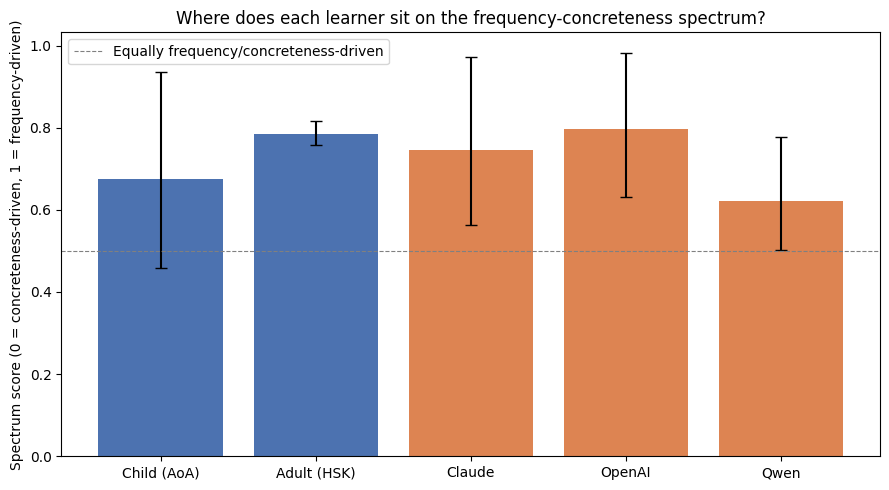

In [ ]:
plt.figure(figsize=(9, 5))
colors = ['#4C72B0' if l in ('Child (AoA)', 'Adult (HSK)') else '#DD8452' for l in spectrum_summary['Learner']]
plt.bar(spectrum_summary['Learner'], spectrum_summary['spectrum_score'], color=colors)
plt.errorbar(
    spectrum_summary['Learner'], spectrum_summary['spectrum_score'],
    yerr=[spectrum_summary['spectrum_score'] - spectrum_summary['ci_lower'],
          spectrum_summary['ci_upper'] - spectrum_summary['spectrum_score']],
    fmt='none', ecolor='black', capsize=4
)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Equally frequency/concreteness-driven')
plt.ylabel('Spectrum score (0 = concreteness-driven, 1 = frequency-driven)')
plt.title('Where does each learner sit on the frequency-concreteness spectrum?')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
for name, df in [('Claude', df_claude_analysis), ('OpenAI', df_openai_analysis), ('Qwen', df_qwen_analysis)]:
    agree_rate = df.groupby(pd.cut(df['hsk_level'], bins=3), observed=True)['can_use_in_sentence'].mean()
    print(f"\n{name}: proportion claiming 'can use in sentence', by HSK tier")
    print(agree_rate)


Claude: proportion claiming 'can use in sentence', by HSK tier
hsk_level
(0.995, 2.667]    1.0
(2.667, 4.333]    1.0
(4.333, 6.0]      1.0
Name: can_use_in_sentence, dtype: float64

OpenAI: proportion claiming 'can use in sentence', by HSK tier
hsk_level
(0.995, 2.667]    1.0
(2.667, 4.333]    1.0
(4.333, 6.0]      1.0
Name: can_use_in_sentence, dtype: float64

Qwen: proportion claiming 'can use in sentence', by HSK tier
hsk_level
(0.995, 2.667]    1.0
(2.667, 4.333]    1.0
(4.333, 6.0]      1.0
Name: can_use_in_sentence, dtype: float64


All five learners score above 0.5 on the spectrum, leaning frequency-driven, but confidence intervals overlap heavily across nearly every pair (Child [0.458, 0.935] alone overlaps with all four others), so this sample cannot confidently distinguish their exact position. Only Adult (HSK), with by far the largest word count (3269 vs ~200-500 for the others), gives a precise estimate (0.785, CI [0.758, 0.817]).

This spectrum score, computed here as a raw bivariate Spearman correlation, disagrees with Section 4.1's Lasso-based finding that children weigh frequency and concreteness almost equally (-1.01 vs -1.04) - Lasso controls for each feature's independent contribution, while this measure does not, so some of concreteness's effect likely leaks into the frequency correlation given that the two are probably correlated with each other. The partial-correlation check below tests this directly.

The 'can_use_in_sentence' field turned out to be uninformative - all three models report 100% willingness across every difficulty tier, a ceiling effect suggesting that models rarely self-report inability regardless of actual word difficulty. On the other hand, 'confidence' shows real variation and is therefore the more useful signal of the structured fields collected.

#### 4.4.4 Robustness check: partial correlation
Lasso (Section 4.1) controls for each feature's independent contribution, but the spectrum score above does not. This repeats the spectrum score using partial Spearman correlation instead of raw bivariate correlation - closer in spirit to what Lasso measures and a direct test of whether frequency-concreteness collinearity is inflating the raw scores above.

In [ ]:
spectrum_results_partial = []

child_spec_p = ev.compute_partial_spectrum_score(df_child_analysis, 'aoa')
adult_spec_p = ev.compute_partial_spectrum_score(df_adult_analysis, 'hsk_level')
spectrum_results_partial.append({'Learner': 'Child (AoA)', **child_spec_p})
spectrum_results_partial.append({'Learner': 'Adult (HSK)', **adult_spec_p})

for name, df in [('Claude', df_claude_analysis), ('OpenAI', df_openai_analysis), ('Qwen', df_qwen_analysis)]:
    spec_p = ev.compute_partial_spectrum_score(df, 'confidence')
    spectrum_results_partial.append({'Learner': name, **spec_p})

spectrum_summary_partial = pd.DataFrame(spectrum_results_partial)
cols = ['partial_spectrum_score', 'ci_lower', 'ci_upper', 'partial_r_freq', 'partial_r_conc']
spectrum_summary_partial[cols] = spectrum_summary_partial[cols].round(3)
spectrum_summary_partial


,Learner,partial_r_freq,partial_r_conc,partial_spectrum_score,ci_lower,ci_upper
0,Child (AoA),-0.307,-0.225,0.576,0.482,0.699
1,Adult (HSK),-0.697,-0.217,0.763,0.736,0.792
2,Claude,0.376,0.135,0.736,0.556,0.972
3,OpenAI,0.465,0.130,0.782,0.626,0.981
4,Qwen,0.405,0.257,0.611,0.503,0.759


In [ ]:
comparison = spectrum_summary[['Learner', 'spectrum_score']].merge(
    spectrum_summary_partial[['Learner', 'partial_spectrum_score']], on='Learner'
)
comparison['shift'] = (comparison['partial_spectrum_score'] - comparison['spectrum_score']).round(3)
comparison


,Learner,spectrum_score,partial_spectrum_score,shift
0,Child (AoA),0.674,0.576,-0.098
1,Adult (HSK),0.785,0.763,-0.022
2,Claude,0.745,0.736,-0.009
3,OpenAI,0.796,0.782,-0.014
4,Qwen,0.622,0.611,-0.011


The partial correlation check confirms the raw spectrum scores in Section 4.4.3 were not meaningfully distorted by frequency-concreteness collinearity: every shift is small and negative, the largest being Child (AoA) at -0.098 and no learner's position relative to the 0.5 midpoint changes. This does not, however, resolve the disagreement with Section 4.1's Lasso coefficients - the partial spectrum score for children still lands on the frequency-leaning side (0.576), while Lasso found near-equal weighing. That gap between methods appears to be a genuine difference in what each measures rather than an artifact of not controlling for collinearity, and is left an open point rather that a resolved one.

## 5. Results

In [ ]:
results_summary = pd.DataFrame([
    {'Population': 'Child AoA', 'Model': 'Ridge (hand-picked features)', 'Test R2': r2_score(y_c_test, y_c_pred)},
    {'Population': 'Child AoA', 'Model': 'Dense NN (hand-picked features)', 'Test R2': metrics_nn_child['r2']},
    {'Population': 'Child AoA', 'Model': 'Dense NN (MacBERT embeddings)', 'Test R2': metrics_nn_child_emb['r2']},
    {'Population': 'Adult HSK', 'Model': 'Ridge (hand-picked features)', 'Test R2': r2_score(y_a_test, y_a_pred)},
    {'Population': 'Adult HSK', 'Model': 'Dense NN (hand-picked features)', 'Test R2': metrics_nn_adult['r2']},
    {'Population': 'Adult HSK', 'Model': 'Dense NN (MacBERT embeddings)', 'Test R2': metrics_nn_adult_emb['r2']},
])
results_summary['Test R2'] = results_summary['Test R2'].round(3)
results_summary

,Population,Model,Test R2
0,Child AoA,Ridge (hand-picked features),-0.155
1,Child AoA,Dense NN (hand-picked features),-0.329
2,Child AoA,Dense NN (MacBERT embeddings),-0.729
3,Adult HSK,Ridge (hand-picked features),0.509
4,Adult HSK,Dense NN (hand-picked features),0.555
5,Adult HSK,Dense NN (MacBERT embeddings),0.454


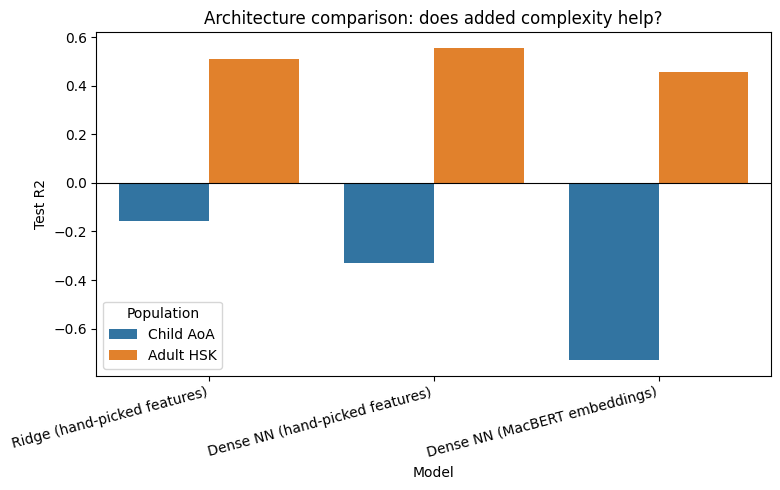

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_summary, x='Model', y='Test R2', hue='Population')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=15, ha='right')
plt.title('Architecture comparison: does added complexity help?')
plt.tight_layout()
plt.show()

The pattern is consistent in direction, though not uniformly confirmed once uncertainty is accounted for (see Section 6). For adults, both differences hold up under bootstrap resampling: a dense NN on the same three hand-picked features given a small but real edge over Ridge ($R^2$=0.555 vs 0.509 - the 95% CI on this difference excludes zero), and richer 768-dimensional embeddings make things reliably worse ($R^2$=0.454, again a real difference). For children, the point estimates trend the same direction - Ridge ($R^2$=-0.155) -> NN on features ($R^2$=-0.329) -> NN on embeddings ($R^2$=-0.729), but only part of this trend survives scrutiny: both NN variants are confirmed worse than a trivial baseline (i.e. worse than simply predicting the mean AoA, their bootstrap CIs sit entirely below zero), yet the further drop from features to embeddings, despite looking like the largest gap in the whole table, has a confidence interval that includes zero. In other words, the child model reliably gets worse with more model capacity, but this dataset is not large enough to say confidently how much worse each additional step makes it.

Two things seem to be happening here. For adults, the drop from NN-on-features to NN-on-embeddings suggests the three hand-picked features already capture most of what predicts HSK difficulty - 768 embedding dimensions add mostly noise on top of a strong signal and there is enough test data (818 words) to say so with confidence. For children, the much smaller training set (378 words) and test set (126 words) make every added parameter riskier and every comparison noisier: the direction of the effect is clear, but its exact size isnt something this dataset can pin down. This is the same overfitting risk flagged before building this section, now visible as a real (though partially uncertain) result rather than a hypothetical concern.

## 6. Uncertainty Analysis
Section 5's comparisons treated single $R^2$ numbers as if they were exact, but every one of them came from one particular train/test split of a few hundred words. Here, paired bootstrap resampling checks whether the differences in Section 5 are large relative to the noise a small test set introduces, before they are used to support any claim.

In [ ]:
import evaluation as ev

print("=== Child AoA ===")
for name, y_pred in [('Ridge', y_c_pred),
                      ('Dense NN (features)', metrics_nn_child['y_pred']),
                      ('Dense NN (embeddings)', metrics_nn_child_emb['y_pred'])]:
    point, lo, hi = ev.bootstrap_r2_ci(y_c_test, y_pred)
    print(f"{name:<25}: R2 = {point:6.3f}  95% CI [{lo:6.3f}, {hi:6.3f}]")

print("\n=== Adult HSK ===")
for name, y_pred in [('Ridge', y_a_pred),
                      ('Dense NN (features)', metrics_nn_adult['y_pred']),
                      ('Dense NN (embeddings)', metrics_nn_adult_emb['y_pred'])]:
    point, lo, hi = ev.bootstrap_r2_ci(y_a_test, y_pred)
    print(f"{name:<25}: R2 = {point:6.3f}  95% CI [{lo:6.3f}, {hi:6.3f}]")

=== Child AoA ===
Ridge                    : R2 = -0.155  95% CI [-0.492,  0.099]
Dense NN (features)      : R2 = -0.329  95% CI [-0.641, -0.087]
Dense NN (embeddings)    : R2 = -0.729  95% CI [-1.546, -0.181]

=== Adult HSK ===
Ridge                    : R2 =  0.509  95% CI [ 0.460,  0.549]
Dense NN (features)      : R2 =  0.555  95% CI [ 0.500,  0.604]
Dense NN (embeddings)    : R2 =  0.454  95% CI [ 0.408,  0.495]


In [ ]:
print("=== Child AoA: features vs. embeddings ===")
diff, lo, hi = ev.bootstrap_r2_diff(y_c_test, metrics_nn_child['y_pred'], metrics_nn_child_emb['y_pred'])
print(f"R2 diff (features - embeddings): {diff:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
print(f"Real difference (CI excludes zero)? {lo > 0 or hi < 0}")

print("\n=== Adult HSK: features vs. embeddings ===")
diff, lo, hi = ev.bootstrap_r2_diff(y_a_test, metrics_nn_adult['y_pred'], metrics_nn_adult_emb['y_pred'])
print(f"R2 diff (features - embeddings): {diff:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
print(f"Real difference (CI excludes zero)? {lo > 0 or hi < 0}")

print("\n=== Adult HSK: Ridge vs. Dense NN (features) ===")
diff, lo, hi = ev.bootstrap_r2_diff(y_a_test, y_a_pred, metrics_nn_adult['y_pred'])
print(f"R2 diff (Ridge - NN): {diff:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
print(f"Real difference (CI excludes zero)? {lo > 0 or hi < 0}")

=== Child AoA: features vs. embeddings ===
R2 diff (features - embeddings): 0.400  95% CI [-0.077, 1.046]
Real difference (CI excludes zero)? False

=== Adult HSK: features vs. embeddings ===
R2 diff (features - embeddings): 0.101  95% CI [0.048, 0.148]
Real difference (CI excludes zero)? True

=== Adult HSK: Ridge vs. Dense NN (features) ===
R2 diff (Ridge - NN): -0.046  95% CI [-0.064, -0.028]
Real difference (CI excludes zero)? True


Two of the three Section 5 comparisons hold up: for adults, both the embeddings-vs-features drop (diff=0.101, 95% CI [0.048, 0.148]) and the Ridge-vs-NN edge (diff=-0.046, CI [-0.064, -0.028]) are real, since neither interval includes zero. For children, the feature-vs-embeddings drop looks like the largest effect in the whole table by raw $R^2$ (-0.329 vs -0.729), but its CI ([-0.077, 1.046]) includes zero - this dataset's 126-word test set is not large enough to confirm that specific step, even though both NN variants individually test as reliably worse than a trivial baseline (their own CIs, [-0.641, -0.087] and [-1.546, -0.181], sit entirely below zero).

## 7. Error Analysis
Where do the models diverge most from human data and why? Rather than a single MAE number, errors are stratified by frequency, concreteness, and word length (the same variables the models are built on), with bootstrap CIs per stratum plus a direct check on whether the three models fail on the same words or different ones.

In [ ]:
child_errors = df_child_analysis.iloc[idx_c_test][['word', 'log_frequency', 'concreteness', 'word_length']].copy()
child_errors['aoa_true'] = y_c_test
child_errors['ridge_abs_err'] = np.abs(y_c_test - y_c_pred)
child_errors['nn_feat_abs_err'] = np.abs(y_c_test - metrics_nn_child['y_pred'])
child_errors['nn_emb_abs_err'] = np.abs(y_c_test - metrics_nn_child_emb['y_pred'])

adult_errors = df_adult_analysis.iloc[idx_a_test][['word', 'log_frequency', 'concreteness', 'word_length']].copy()
adult_errors['hsk_true'] = y_a_test
adult_errors['ridge_abs_err'] = np.abs(y_a_test - y_a_pred)
adult_errors['nn_feat_abs_err'] = np.abs(y_a_test - metrics_nn_adult['y_pred'])
adult_errors['nn_emb_abs_err'] = np.abs(y_a_test - metrics_nn_adult_emb['y_pred'])

print(f"Child error table: {child_errors.shape}")
print(f"Adult error table: {adult_errors.shape}")

Child error table: (126, 8)
Adult error table: (818, 8)


This builds a per-word error table for each population, joining held-out test predictions from all three models back to their frequency, concreteness and length metadata.

In [ ]:
error_cols = ['ridge_abs_err', 'nn_feat_abs_err', 'nn_emb_abs_err']

for strat_col in ['log_frequency', 'concreteness', 'word_length']:
    print(f"\n{'='*20} Child AoA — by {strat_col} {'='*20}")
    display(ev.stratified_error_analysis(child_errors, error_cols, strat_col))

    print(f"\n{'='*20} Adult HSK — by {strat_col} {'='*20}")
    display(ev.stratified_error_analysis(adult_errors, error_cols, strat_col))


==================== Child AoA — by log_frequency ====================


,bucket,model,n,mean_error,ci_lower,ci_upper
0,"(2.1060000000000003, 3.192]",ridge_abs_err,26,1.558,0.865,2.453
1,"(2.1060000000000003, 3.192]",nn_feat_abs_err,26,1.873,1.144,2.788
2,"(2.1060000000000003, 3.192]",nn_emb_abs_err,26,2.071,1.340,3.085
3,"(3.192, 3.637]",ridge_abs_err,25,1.653,1.145,2.254
4,"(3.192, 3.637]",nn_feat_abs_err,25,1.521,1.098,1.976
5,"(3.192, 3.637]",nn_emb_abs_err,25,1.648,1.147,2.239
6,"(3.637, 4.009]",ridge_abs_err,25,1.150,0.860,1.458
7,"(3.637, 4.009]",nn_feat_abs_err,25,1.219,0.865,1.672
8,"(3.637, 4.009]",nn_emb_abs_err,25,2.511,1.803,3.405
9,"(4.009, 4.339]",ridge_abs_err,25,2.633,1.782,3.446



==================== Adult HSK — by log_frequency ====================


,bucket,model,n,mean_error,ci_lower,ci_upper
0,"(1.461, 2.624]",ridge_abs_err,164,0.460,0.396,0.527
1,"(1.461, 2.624]",nn_feat_abs_err,164,0.331,0.277,0.392
2,"(1.461, 2.624]",nn_emb_abs_err,164,0.612,0.550,0.679
3,"(2.624, 3.008]",ridge_abs_err,163,0.640,0.572,0.711
4,"(2.624, 3.008]",nn_feat_abs_err,163,0.618,0.548,0.688
5,"(2.624, 3.008]",nn_emb_abs_err,163,0.709,0.628,0.794
6,"(3.008, 3.315]",ridge_abs_err,164,0.763,0.673,0.861
7,"(3.008, 3.315]",nn_feat_abs_err,164,0.731,0.640,0.828
8,"(3.008, 3.315]",nn_emb_abs_err,164,0.726,0.642,0.820
9,"(3.315, 3.72]",ridge_abs_err,163,0.838,0.744,0.930



==================== Child AoA — by concreteness ====================


...

,bucket,model,n,mean_error,ci_lower,ci_upper
0,"(0.037899999999999996, 0.324]",ridge_abs_err,165,0.528,0.469,0.593
1,"(0.037899999999999996, 0.324]",nn_feat_abs_err,165,0.463,0.405,0.526
2,"(0.037899999999999996, 0.324]",nn_emb_abs_err,165,0.594,0.533,0.651
3,"(0.324, 0.443]",ridge_abs_err,174,0.562,0.498,0.633
4,"(0.324, 0.443]",nn_feat_abs_err,174,0.510,0.453,0.570
5,"(0.324, 0.443]",nn_emb_abs_err,174,0.706,0.632,0.787
6,"(0.443, 0.575]",ridge_abs_err,152,0.708,0.619,0.804
7,"(0.443, 0.575]",nn_feat_abs_err,152,0.665,0.573,0.759
8,"(0.443, 0.575]",nn_emb_abs_err,152,0.780,0.682,0.887
9,"(0.575, 0.749]",ridge_abs_err,164,0.813,0.722,0.898



==================== Child AoA — by word_length ====================


,bucket,model,n,mean_error,ci_lower,ci_upper
0,"(0.99999999999999, 1.00000000000001]",ridge_abs_err,76,1.463,1.198,1.749
1,"(0.99999999999999, 1.00000000000001]",nn_feat_abs_err,76,1.638,1.371,1.939
2,"(0.99999999999999, 1.00000000000001]",nn_emb_abs_err,76,2.434,2.023,2.911
3,"(1.00000000000001, 2.0]",ridge_abs_err,50,2.265,1.736,2.965
4,"(1.00000000000001, 2.0]",nn_feat_abs_err,50,2.454,1.898,3.142
5,"(1.00000000000001, 2.0]",nn_emb_abs_err,50,2.030,1.482,2.700



==================== Adult HSK — by word_length ====================


,bucket,model,n,mean_error,ci_lower,ci_upper
0,"(0.999, 2.0]",ridge_abs_err,818,0.720,0.679,0.762
1,"(0.999, 2.0]",nn_feat_abs_err,818,0.664,0.624,0.704
2,"(0.999, 2.0]",nn_emb_abs_err,818,0.775,0.728,0.816


Error increases monotonically with both frequency and concreteness for adult HSK across all three models - a floor effect concentrated in common concrete HSK1 vocabulary, while the child patterns are noisier given the smaller bucket sizes (~25 words each), and word length turns out to be an uninformative stratification variable for either population.

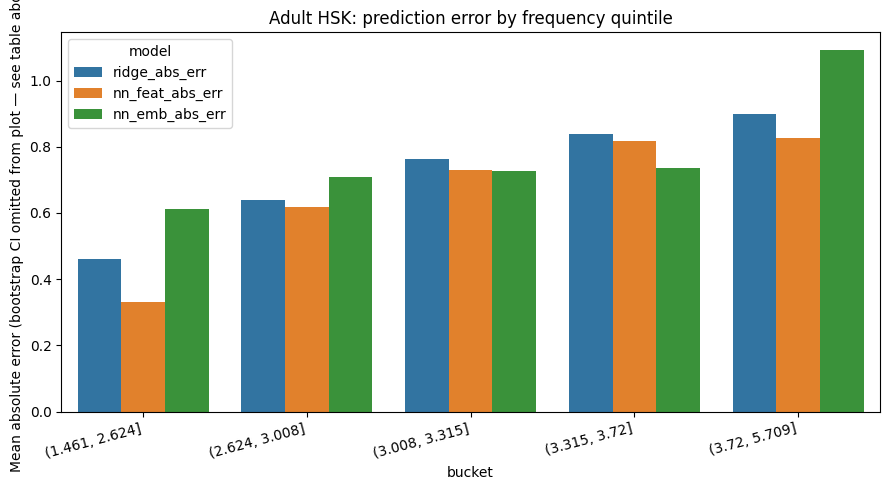

In [ ]:
adult_freq_strat = ev.stratified_error_analysis(adult_errors, error_cols, 'log_frequency')
plt.figure(figsize=(9, 5))
sns.barplot(data=adult_freq_strat, x='bucket', y='mean_error', hue='model')
plt.xticks(rotation=15, ha='right')
plt.title('Adult HSK: prediction error by frequency quintile')
plt.ylabel('Mean absolute error (bootstrap CI omitted from plot — see table above)')
plt.tight_layout()
plt.show()

The chart makes the floor effect visually clear - error climbs steadily from the lowest to the highest frequency quintile across all three models, confirming that HSK1's common words are the hardest to distinguish, not the easiest.

In [ ]:
print("=== Child AoA: cross-model error correlation (Spearman) ===")
r1, p1 = spearmanr(child_errors['ridge_abs_err'], child_errors['nn_feat_abs_err'])
r2, p2 = spearmanr(child_errors['nn_feat_abs_err'], child_errors['nn_emb_abs_err'])
print(f"Ridge vs NN(features):        rho={r1:.3f}, p={p1:.3f}")
print(f"NN(features) vs NN(embeddings): rho={r2:.3f}, p={p2:.3f}")

print("\n=== Adult HSK: cross-model error correlation (Spearman) ===")
r3, p3 = spearmanr(adult_errors['ridge_abs_err'], adult_errors['nn_feat_abs_err'])
r4, p4 = spearmanr(adult_errors['nn_feat_abs_err'], adult_errors['nn_emb_abs_err'])
print(f"Ridge vs NN(features):        rho={r3:.3f}, p={p3:.3f}")
print(f"NN(features) vs NN(embeddings): rho={r4:.3f}, p={p4:.3f}")

=== Child AoA: cross-model error correlation (Spearman) ===
Ridge vs NN(features):        rho=0.729, p=0.000
NN(features) vs NN(embeddings): rho=0.176, p=0.048

=== Adult HSK: cross-model error correlation (Spearman) ===
Ridge vs NN(features):        rho=0.837, p=0.000
NN(features) vs NN(embeddings): rho=0.393, p=0.000


Ridge and the features-based NN fail on largely the same words (ρ=0.73 for children, ρ=0.84 for adults, but the errors of NN (embeddings) correlate much more weakly with NN(features) for children (ρ=0.18, only marginally significant at p=0.048) than for adults (ρ=0.39, clearly significant). This means that the embeddings model is not just doing worse on the child data, it is failing on a substantially different set of words that the other two models.

In [ ]:
print("=== Child AoA: 10 hardest words for Ridge ===")
print(child_errors.nlargest(10, 'ridge_abs_err')[['word', 'aoa_true', 'ridge_abs_err']].to_string(index=False))

print("\n=== Adult HSK: 10 hardest words for Ridge ===")
print(adult_errors.nlargest(10, 'ridge_abs_err')[['word', 'hsk_true', 'ridge_abs_err']].to_string(index=False))

=== Child AoA: 10 hardest words for Ridge ===
word  aoa_true  ridge_abs_err
  旺旺      16.0      10.173161
  男人      28.0       7.723225
  中国      27.0       6.963240
   头      25.0       6.860152
  再见      16.0       6.002468
  伯伯      16.0       5.680822
  昨天      27.0       5.264911
  袜子      17.0       4.749547
  牛奶      17.0       4.531091
  害怕      19.0       4.514401

=== Adult HSK: 10 hardest words for Ridge ===
word  hsk_true  ridge_abs_err
  米饭         1       3.959637
  商店         1       3.876187
  星期         1       3.666333
  杯子         1       3.461431
  天气         1       3.400441
   冷         1       2.936460
  桌子         1       2.846402
   茶         1       2.735111
  漂亮         1       2.686185
  认识         1       2.583057


Interestingly, all ten hardest adult words are HSK level 1 - common, concrete vocabulary like 米饭 (rice) and 杯子 (cup), which directly illustrates the floor effect. The child list is messier and includes at least one likely special case (旺旺 - woof woof) worth a more detailed qualitative look.

The clearest result in this section is a floor effect for adult HSK prediction, showing that the models struggle most on exactly the words HSK design treats as "easiest" - common, concrete, HSK1 vocabulary. This matches the worst-word inspection directly - each of the ten hardest words for Ridge was HSK1. Rarer, more abstract words are predicted more accurately, likely because they are spread across a wider difficulty range rather than compressed into one narrow band.

For children, the same stratifications are much noisier than for adults, and the finding that both neural models underperform the mean baseline (the embeddings vs features contrast remaining inconclusive)  does not cleanly localize to specific difficulty slices: NN(embeddings) is the worst performer in half of the frequency/concreteness/length buckets (6 of 12), with NN(features) close behind (5 of 12). At this sample size (~25 words per bucket), the per-slice ranking is too unstable to say more than that both neural variants are inconsistently worse than Ridge. This is consistent with Section 6's finding that the overall features vs embeddings gap for children is not statistically distinguishable from noise: the instability shows up at the granular level too, not just in the headline $R^2$ comparison.

Word length turned out not to be a useful stratification variable - HSK vocabulary is almost entirely uniform in character length, collapsing to a single bucket for adults, and the child-only two-bucket split (50-76 words each) is too small to distinguish a real pattern from noise.

## 8. Discussion
This project tried to answer two main questions and it seems that they kind of answered each other.

Sections 4.1 - 4.3 asked whether more model capacity helps predict word-acquisition difficulty, and the answer was no: the three hand-picked features (frequency, concreteness, length) already capture most of the real signal. Adding a dense newtork and then high-dimensional embeddings produced no reliable gains for adults and clear degradation relative to the mean baseline for children (the further embeddings step itself remains inconclusive given the small test set).

That finding directly shaped how Section 4.4 was built. Rather than trying to extract something elaborate from each LLM, it asked the plain direct question: what does the model itself says it knows about a word? The result echoes Section 4.1's lesson from a different angle: all three models (Claude, GPT, Qwen) lean toward the same frequency-driven profile as the adult HSK learners, but with only 200 words tested per model, this dataset cannot confidently separate their exact positions from each other or from the human data.

This is also, I think, the answer to the question that motivated the whole project: whether the Chinese BabyLM Challenge's evaluation pipeline is missing something by not including an acquisition-order comparison. Section 4.4's methodology - asking a model directly, scoring its self-reported confidence, comparing that against real child and adult acquisition data, was a genuine first attempt at that missing piece, even if this particular run is underpowered to draw strong conclusions from.




## 9. Limitations & Future Work
**Sample size asymmetry between the two halves of this project.** Sections 4.1 - 4.3 draw on 504-3269 words with real statistical power especially for adults. Section 4.4's LLM testing used only 200 words per model - probably enough to see a consistent direction but definitely not enough to confidently rank models against each other or against the human baselines. A larger API sample is the most direct way to strengthen this project's central finding.

**The spectrum score and Section 4.1's Lasso coefficients disagreed for children** - the raw bivariate spectrum score suggested frequency-leaning, while Lasso suggested near-equal weighting. Section 4.4.4's partial correlation check tests this directly and the disagreement persisted (partial spectrum score 0.576, still frequency-leaning). This looks like a genuine difference in what the two methods measure and is left open here.

**The 'can_use_in_sentence' field, one of the two structured fields collected from each LLM, turned out to be uninformative** - all three models reported 100% willingness regardless of a actual word difficulty, a ceiling effect rather than a behavioral signal. The other field, 'confidence', was the one that actually carried information.

**Small-N and high-dimensional embeddings compound each other** - the child model's 378 training examples make the 786-dimensional MacBERT embeddings meaningfully more prone to overfitting than the three hand-picked features - visible directly in Sections 5-7's results.

**Tokenization differs across MacBERT, Claude, GPT and Qwen**, complicating precisely comparing "the same word", even though Section 4.4's behavioral comparison sidedteps this by working at the whole-world level rather tham the token level.

**This project is Mandarin-only.** Testing whether the same two-part pattern - complexity does not help prediction, and real LLMs lean adult-like, holds for other languages as well is a natural next step.

**All three models were tested through each provider's structured-output API**, which reflects each model's post-training/alignment behavior on this specific task framing. A different prompt structure, or access to a genuinely raw/base model, might surface different confidence patterns.





## 10. Conclusion
This project set out to test an assumption my ML project had made rather than measured: that a language model's "acquisition profile" looks like a frequency-maximizing adult learner. Testing that directly meant first understanding what actually improves word-difficulty prediction at all. And the answer, across Ridge, Random Forest, dense neural networks, and pretrained transformer embeddings, was that added complexity mostly does not help, amd even actively hurts for the smaller child dataset. That lesson shaped a deliberately simple design for testing LLMs directly - ask each model what it knows about a word and compare its self-reported confidence against real human acquisition data.

The result: Claude, GPT and Qwen all lean toward the same frequency-driven pattern as adult L2 learners, consistent with, though less strongly confirmed than, the assumption my earlier project made. Whether this holds up with a larger sample, or generalizes beyond Mandarin, are questions for a larger study.

## 11. References

- Findings of the BabyLM Challenge: Sample-Efficient Pretraining on Developmentally Plausible Corpora (Warstadt et al., CoNLL-BabyLM 2023) https://aclanthology.org/2023.conll-babylm.1/
- BabyBabelLM: A Multilingual Benchmark of Developmentally Plausible Training Data (Jumelet et al., EACL 2026), https://aclanthology.org/2026.eacl-long.152/
- Chinese BabyLM Challenge (2026). Co-located with NLPCC 2026. https://chinese-babylm.github.io/

#### Datasets:
- Frank, M.C., Braginsky, M., Yurovsky, D., & Marchman, V.A. (2017). Wordbank: An open repository for developmental vocabulary data. Journal of Child Language, 44(3), 677–694. Available at: https://wordbank.stanford.edu, Accessed on 2026-06-07

- Hu, M. et al. Chinese BabyLM Challenge corpus (Available at: https://huggingface.co/datasets/chinese-babylm-org/babylm-zho-100M, Accessed on 2026-06-07, Processed and saved as a csv file available here: https://drive.google.com/file/d/1sb2_Fq67EGy6WySI-44L16wUytFeVlJY/view?usp=drive_link)

- HSK Vocabulary Lists (old HSK system, 6 levels). Available at: https://github.com/plaktos/hsk_csv, Accessed on 2026-06-07

- Xu, X. & Li, J. (2020). Concreteness ratings for 9,877 two-character Chinese words. PLOS ONE, 15(5), e0232133. Available at: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0232133 , Accessed on 2026-06-07

- Liu, Y., Shu, H., & Li, P. (2007). Word naming and psycholinguistic norms: Chinese. Behavior Research Methods, 39, 192–198. Database available at the Chinese Single-character Word Database (CSWD) at https://blclab.org/introduction-to-the-database/, accessed on 2026-06-11

- All datasets available here: https://drive.google.com/drive/folders/13qEDS3YRXskJjXPesqNmPn9uImHmopVl?usp=drive_link

